<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Project1/StatsML_Project1_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Racial Biases in Hiring: The Effect of Race on Hiring Practices
Aydan Ali

Statistics and Machine Learning: Project 1 Phase 3

03.18.2026

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

df_raw = pd.read_csv('gdrive/My Drive/callbacks_experiement_data.csv')
df = df_raw.fillna(0)

df

Mounted at /content/gdrive


,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,1344,Boston,finance_insurance_real_estate,secretary,0.0,0,private,1,0,0,...,0,0,1,1,1,0,0,1,0,low
4866,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,6,1,0,0,0,0,0,low
4867,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,8,1,0,1,0,0,1,high
4868,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,2,1,0,1,1,0,1,high


Above is the cleaned dataset that the regressions will be ran on. The dataset was nearly complete with missing values in `job_fed_contractor` and `job_req_min_experience`. Given the cleanliness and structure of the data, I determined the data was structurally missing and not random missing value (MCAR). The missing data (NaN, NA, or blanks) were null or 0 values. To clean the imported dataframe I filled the blanks/NaN with 0s.

-1.0 15.0
[22 21 19 23 18 26 25 16 20 17 44]


Text(0, 0.5, 'years_experience')

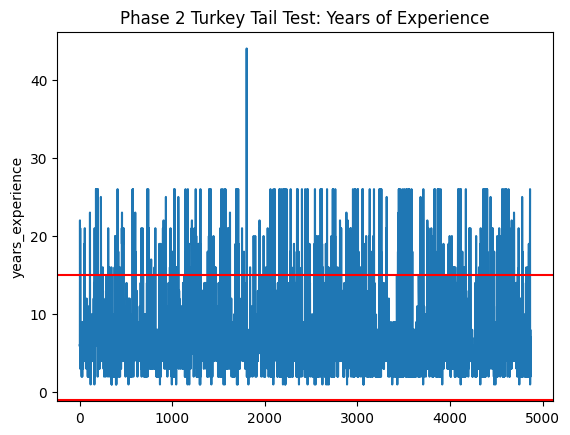

In [ ]:
# Manual Tukey Fence implementation
Q1 = df['years_experience'].quantile(0.25)
Q3 = df['years_experience'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['years_experience'] < (Q1 - 1.5 * IQR)) | (df['years_experience'] > (Q3 + 1.5 * IQR))]
print(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
print(outliers['years_experience'].unique())


index = range(len(df))
plt.plot(index, df['years_experience'])
plt.axhline(Q3 + 1.5 * IQR, color='r')
plt.axhline(Q1 - 1.5 * IQR, color='r')
plt.title('Phase 2 Tukey Fence: Years of Experience')
plt.ylabel('years_experience')

Above is the manual Tukey Fence method of finding outliers. In the previous phase, I claimed that there would be no outliers give then data is made-up, but I still wanted to run this test to the distribution of the variable `years_experience`. This variable showed many outliers (all instances above the red line), but given the nature of the data I do not feel that they should be removed. Instead, they are worth flagging as resumes that are higher quality or can pose as outlier applicants that skews the data.

Text(0, 0.5, 'Callback Rate')

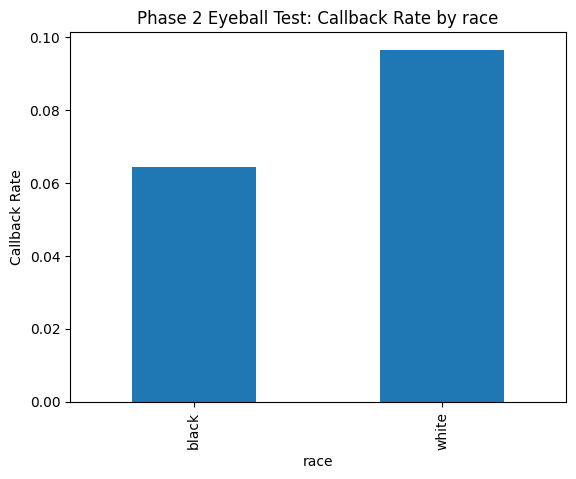

In [ ]:
callback_rates = df.groupby('race')['received_callback'].mean()
callback_rates.plot(kind='bar')

plt.title('Phase 2 Eyeball Test: Callback Rate by race')
plt.ylabel('Callback Rate')

Now, we want to find any significance in the data. First, we want to look at the difference in the callback rates to determine if it is statistically significant. In the last phase, we conducted the "eyeball test," which showed us there was a large difference between the callback rates of black and white applicants. The data is all arbitrary, meaning the original researchers created fake resumes and applicants, randomized statistics, addresses, and sorted into high and low quality resumes. Then, 4 resumes were given to each job posting, one with a high quality black applicant, one with a high quality white applicant, one with a low quality black applicant, and one with a low quality white applicant. Given this, we know that any difference between the two is can only be due to discrimination in hiring. The important check is whether the difference is statsically significant.

It is important to keep in mind the original reserach question during these test: Are white-sounding names more likely to be called back for a job than black-sounding names?

It is important to consider confounding variables in our study. There are many interactions that can affect the results of a study that are not measured and out of the control of the experiment. In our data specifically, I have identified two confounding variables that are not within the data and can affect the results:

The first is the race and experiences of the person in charge of hiring. Someone who is white will likely have a bias towards white names because of the mere-exposure effect (where people tend to prefer or choose familiar things). Given our data does not include information about the race of the hiring teams, we cannot correctly control for this.

Another confounding variable that the paper discusses is the neighborhood and perceieved social class of applicants. The resumes had randomized addresses, so the original authors were able to test whether neighborhood played a role in the hiring process. However, we cannot determine whether the choice of discrimination was because of the percieved race or the perceived social class. With some black names being associated with lower socioeconomic background, a black name might signal more than just a racial bias.

In [ ]:
'''
This list is for me to see the columns and a unique list of their values.
This will help me determine which variables may be good to include in the model.
'''

column_list = df.columns.tolist()

for i in column_list:
  print(i, df[i].unique())

job_ad_id [ 384  385  386 ...  381 1344  382]
job_city ['Chicago' 'Boston']
job_industry ['manufacturing' 'other_service' 'wholesale_and_retail_trade'
 'business_and_personal_service' 'finance_insurance_real_estate'
 'transportation_communication']
job_type ['supervisor' 'secretary' 'sales_rep' 'retail_sales' 'manager' 'clerical']
job_fed_contractor [0. 1.]
job_equal_opp_employer [1 0]
job_ownership ['unknown' 'nonprofit' 'private' 'public']
job_req_any [1 0]
job_req_communication [0 1]
job_req_education [0 1]
job_req_min_experience ['5' 'some' 0 '3' '2' '1' '8' '7' '0.5' '10' '0' '4' '6']
job_req_computer [1 0]
job_req_organization [0 1]
job_req_school ['none_listed' 'some_college' 'college' 'high_school_grad']
received_callback [0 1]
firstname ['Allison' 'Kristen' 'Lakisha' 'Latonya' 'Carrie' 'Jay' 'Jill' 'Kenya'
 'Tyrone' 'Aisha' 'Geoffrey' 'Matthew' 'Tamika' 'Leroy' 'Todd' 'Greg'
 'Keisha' 'Brad' 'Laurie' 'Meredith' 'Anne' 'Emily' 'Latoya' 'Ebony'
 'Brendan' 'Hakim' 'Jamal' 'Neil' 

In [ ]:
# Define the formula string: Y ~ D + X1 + X2
# Note: We use np.log() directly in the formula for Log-Level specification
formula_1 = 'received_callback ~ race + resume_quality + computer_skills + years_experience + college_degree + gender'

# Fit the model
model_1 = smf.probit(formula=formula_1, data=df).fit(cov_type='HC3')

# Print the "Regression Anatomy"
print(model_1.summary())

Optimization terminated successfully.
         Current function value: 0.275716
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4863
Method:                           MLE   Df Model:                            6
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01520
Time:                        08:16:14   Log-Likelihood:                -1342.7
converged:                       True   LL-Null:                       -1363.5
Covariance Type:                  HC3   LLR p-value:                 2.359e-07
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.4598      0.103    -14.136      0.000      -1.662      -1.

This model looks at the basic callback rate as well as a selected few variables that I felt were important to consider when examining the data. All these terms are estimated under "Ceteris Paribus," meaning that all other variables are held constant in order to estimate the effect of a specific variable.

The main test was on race, seen as race[T.white]. These coefficients represent the effect that being white has on callbacks relative to being black. This shows that white applicants are significantly more likely to be callback (0.2135), with extreme statistical significant (p=0.000).

The other variables test are checking the impact they have on callback rates, all else equal. The significant ones to note are:
*   resume_quality, showing weak signiciant
*   computer_skills, showing a negative association meaning that having computer skills hurts an applicant
*   years_experience, showing additional experience increase callback odds and is very statistically significant

In [ ]:
# Interaction Term Syntax (:)
# This model includes: education, female, AND (education * female)
formula_interact = 'received_callback ~ race * resume_quality + computer_skills + years_experience + college_degree + gender'

model_interact = smf.probit(formula=formula_interact, data=df).fit(cov_type='HC3')
print(model_interact.summary())


Optimization terminated successfully.
         Current function value: 0.275618
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4862
Method:                           MLE   Df Model:                            7
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01555
Time:                        08:16:16   Log-Likelihood:                -1342.3
converged:                       True   LL-Null:                       -1363.5
Covariance Type:                  HC3   LLR p-value:                 4.357e-07
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -1.4876      0.108 

In [ ]:
formula_interact_1 = 'received_callback ~ race * years_experience + computer_skills + resume_quality + college_degree + gender'

model_interact_1 = smf.probit(formula=formula_interact_1, data=df).fit(cov_type='HC3')
print(model_interact_1.summary())


Optimization terminated successfully.
         Current function value: 0.275711
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4862
Method:                           MLE   Df Model:                            7
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01522
Time:                        08:16:18   Log-Likelihood:                -1342.7
converged:                       True   LL-Null:                       -1363.5
Covariance Type:                  HC3   LLR p-value:                 6.505e-07
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.4698      0.111    -13.222     

In [ ]:
formula_interact_2 = 'received_callback ~ race * college_degree + computer_skills + resume_quality + years_experience + gender'

model_interact_2 = smf.probit(formula=formula_interact_2, data=df).fit(cov_type='HC3')
print(model_interact_2.summary())

Optimization terminated successfully.
         Current function value: 0.275669
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4862
Method:                           MLE   Df Model:                            7
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01537
Time:                        08:16:19   Log-Likelihood:                -1342.5
converged:                       True   LL-Null:                       -1363.5
Covariance Type:                  HC3   LLR p-value:                 5.415e-07
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -1.4932      0.113    -13.169      0.000

I tested these terms because the original paper notes some differences between the interaction variables and race. After showing the statistical significance in callbacks by race, the authors wondered if there was a difference in how credential of an applicant was affected by race. All of these variables have high p-values, meaning that they are not statistically significant.